In [2]:
#Install seaborn
!pip install seaborn

print("Successful.")

Successful.


In [13]:
#Import the dependables 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
sns.set_style('whitegrid')

In [5]:
# Load the dataset

df = pd.read_csv("2015.csv")

df.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [6]:
#Check the shape of the data

df.shape

(158, 12)

In [7]:
#Check the column names 

df.columns

Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
       'Standard Error', 'Economy (GDP per Capita)', 'Family',
       'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)',
       'Generosity', 'Dystopia Residual'],
      dtype='object')

In [8]:
#Check the info of the data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    object 
 1   Region                         158 non-null    object 
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9), int64(1), object(2)
memory usage: 1

In [9]:
#Check for duplicates

df.duplicated().sum()

np.int64(0)

In [10]:
#Check for the statistical summary of the data. 

df.describe()

,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,79.493671,5.375734,0.047885,0.846137,0.991046,0.630259,0.428615,0.143422,0.237296,2.098977
std,45.754363,1.145010,0.017146,0.403121,0.272369,0.247078,0.150693,0.120034,0.126685,0.553550
min,1.000000,2.839000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580
25%,40.250000,4.526000,0.037268,0.545808,0.856823,0.439185,0.328330,0.061675,0.150553,1.759410
50%,79.500000,5.232500,0.043940,0.910245,1.029510,0.696705,0.435515,0.107220,0.216130,2.095415
75%,118.750000,6.243750,0.052300,1.158448,1.214405,0.811013,0.549092,0.180255,0.309883,2.462415
max,158.000000,7.587000,0.136930,1.690420,1.402230,1.025250,0.669730,0.551910,0.795880,3.602140


In [12]:
# The Economy GDP has a minimum value of 0 among others. Lets check them out


df[(df['Economy (GDP per Capita)'] == 0) | 
   (df['Family'] == 0) | 
   (df['Health (Life Expectancy)'] == 0) | 
   (df['Freedom'] == 0) | 
   (df['Trust (Government Corruption)'] == 0) | 
   (df['Generosity'] == 0)]

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
73,Indonesia,Southeastern Asia,74,5.399,0.02596,0.82827,1.08708,0.63793,0.46611,0.00000,0.51535,1.86399
101,Greece,Western Europe,102,4.857,0.05062,1.15406,0.92933,0.88213,0.07699,0.01397,0.00000,1.80101
111,Iraq,Middle East and Northern Africa,112,4.677,0.05232,0.98549,0.81889,0.60237,0.00000,0.13788,0.17922,1.95335
119,Congo (Kinshasa),Sub-Saharan Africa,120,4.517,0.03680,0.00000,1.00120,0.09806,0.22605,0.07625,0.24834,2.86712
122,Sierra Leone,Sub-Saharan Africa,123,4.507,0.07068,0.33024,0.95571,0.00000,0.40840,0.08786,0.21488,2.51009
147,Central African Republic,Sub-Saharan Africa,148,3.678,0.06112,0.07850,0.00000,0.06699,0.48879,0.08289,0.23835,2.72230


The problem above does not post any serious issue to our work here. So, we leave it as it is. 

## Visualization of the data 

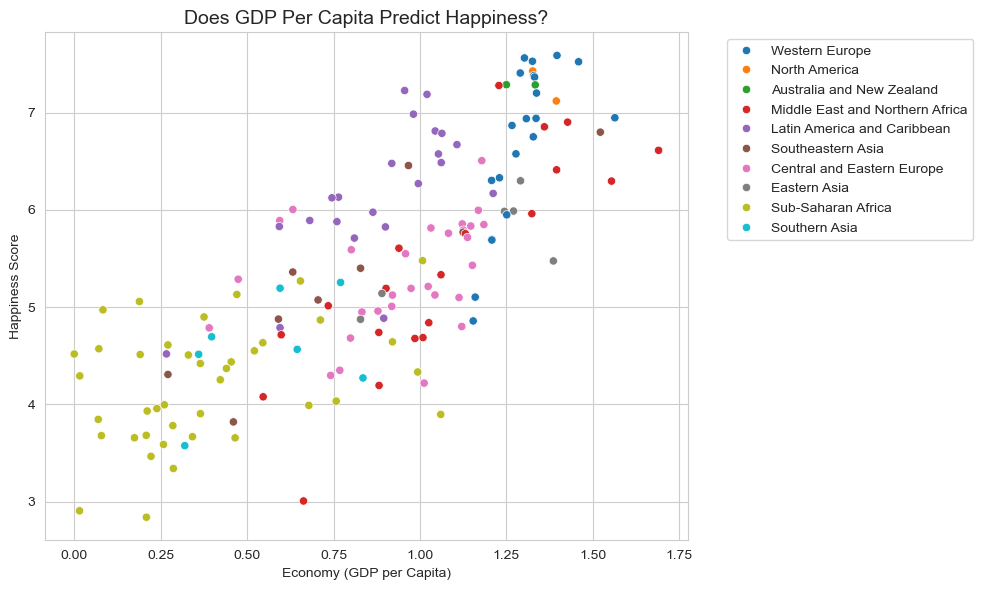

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Economy (GDP per Capita)', y='Happiness Score', hue='Region')
plt.title('Does GDP Per Capita Predict Happiness?', fontsize=14)
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Happiness Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # keeps legend from covering the chart
plt.tight_layout()
plt.savefig('gdp_happiness_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

A scatter plot was built comparing Economy (GDP per Capita) against Happiness Score, color-coded by Region.

Positive relationship: Higher GDP per capita is generally associated with higher happiness scores. The relationship is real but not perfectly linear — GDP does not fully determine happiness, particularly in the mid-GDP range where scores vary widely.

GDP per capita is a meaningful but incomplete predictor of national happiness. Regional and cultural factors — potentially captured in the Family, Freedom, or Trust columns — likely explain some of the variance GDP leaves unaccounted for.

C:\Users\mbwas\AppData\Local\Temp\ipykernel_14272\742668732.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_avg.values, y=region_avg.index, palette='viridis')


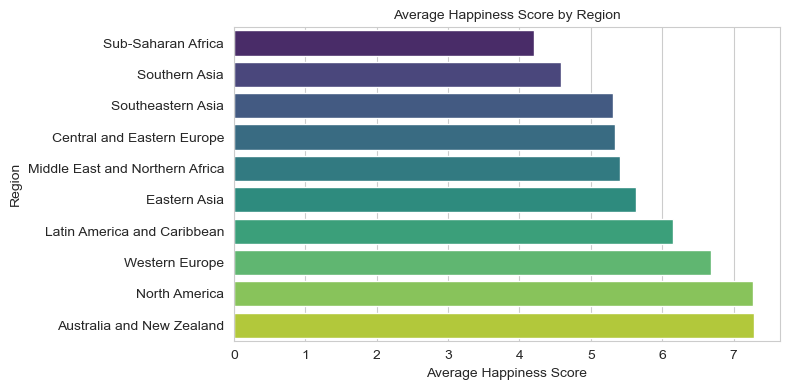

In [20]:
region_avg = df.groupby('Region')['Happiness Score'].mean().sort_values()

plt.figure(figsize=(8, 4))
sns.barplot(x=region_avg.values, y=region_avg.index, palette='viridis')
plt.title('Average Happiness Score by Region', fontsize=10)
plt.xlabel('Average Happiness Score')
plt.ylabel('Region')
plt.tight_layout()
plt.savefig('happiness_by_region.png', dpi=300, bbox_inches='tight')
plt.show()

This chart shows a clear happiness gap between world regions: Sub-Saharan Africa and Southern Asia report the lowest average happiness (around 4–4.5), while North America and Australia/New Zealand report the highest (around 7.3) — a difference of roughly 3 points on the scale, confirming that where a country is located is strongly tied to how happy its people report being.

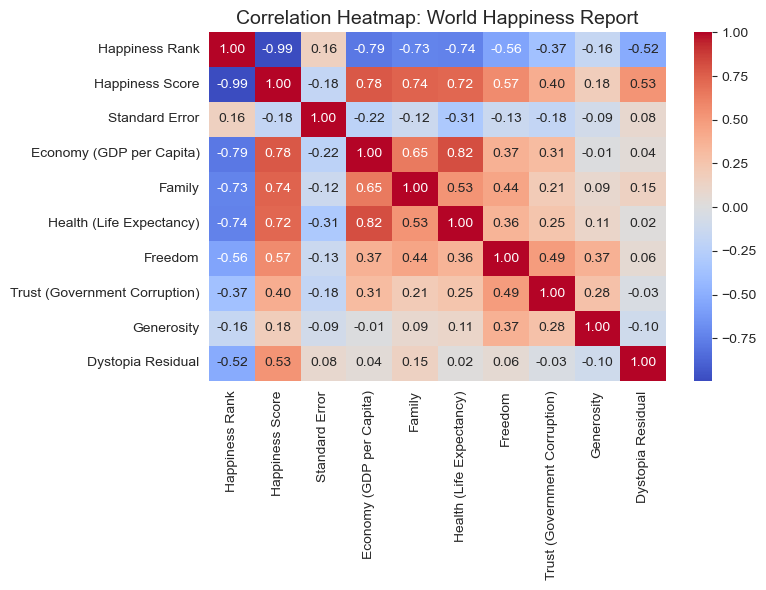

In [22]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: World Happiness Report', fontsize=14)
plt.tight_layout()
plt.savefig('happiness_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

Happiness Score correlates strongly with GDP per Capita (0.78), Health/Life Expectancy (0.72), and Family (0.74) — these three are the biggest drivers of national happiness — while Freedom (0.57) and Trust in Government (0.40) matter moderately, and Generosity barely matters at all (0.18), showing that money, health, and social support explain happiness far better than generosity does.

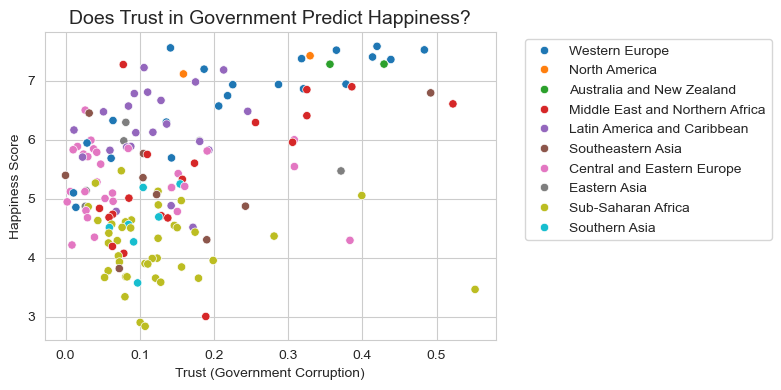

In [26]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='Trust (Government Corruption)', y='Happiness Score', hue='Region')
plt.title('Does Trust in Government Predict Happiness?', fontsize=14)
plt.xlabel('Trust (Government Corruption)')
plt.ylabel('Happiness Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('trust_happiness_scatter.png', dpi=300, bbox_inches='tight')
plt.show()